# 7.데이터프레임 합치기

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 7.1. 데이터프레임 합치기(Concat)

- **concat()** 함수를 사용해 **인덱스 값을 기준으로** 두 데이터프레임을 가로 또는 세로로 합칠 수 있다.
- ```pd.concat(objs, axis=0, join='outer', ignore_index=False)```

    - objs : 합칠 데이터프레임이나 시리즈의 리스트 (예: [df1, df2])
    - axis : 결합 방향: 0(세로, 행 추가), 1(가로, 열 추가)
    - join : outer(기본값, 모든 데이터 포함), inner(공통 항목만 포함)
    - ignore_index : 인덱스를 재설정할지 여부 (True면 새 인덱스 생성)




### 7.1.1.가로로 합치기

- **axis=1** 옵션을 지정해 가로로 합칠 수 있다.
- join 옵션
    - outer (기본값): 모든 인덱스를 포함하며, 일치하지 않는 인덱스에는 NaN 값이 들어감
    - inner: 공통된 인덱스만 포함


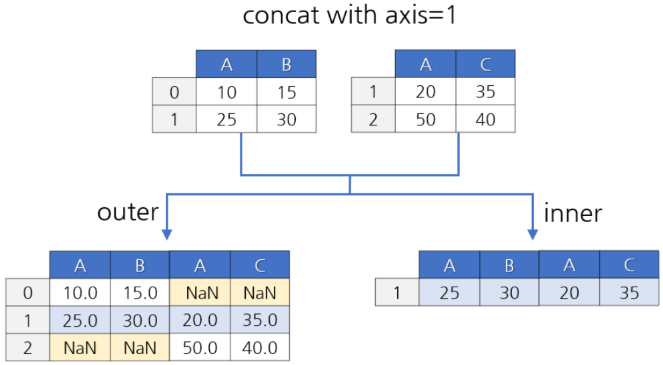

**1) 데이터 읽어오기**

In [ ]:
# 서울 인구 데이터 불러오기 1
path = 'data/seoul_pop_01.csv'
pop01 = pd.read_csv(path, index_col='year')
pop01.index.name = None

pop01.head()

In [ ]:
# 서울 인구 데이터 불러오기 2
path = 'data/seoul_pop_02.csv'
pop02 = pd.read_csv(path, index_col='year')
pop02.index.name = None

pop02.head()

**2) 데이터프레임 합치기**

- 이제 **concat()** 함수를 사용해 두 데이터프레임을 합쳐보자.
- 가로로 합치므로 **axis=1** 옵션을 지정한다.
- join='outer'는 기본 옵션값이므로 생략이 가능하다.

- pop02 데이터프레임에는 1981~1984년 데이터가 없어 합쳐진 결과에 결측치가 생긴다.
- join='inner' 옵션을 지정하면 매핑되지 못한 행은 제외된다.

### 7.1.2.세로로 합치기


- **axis=0** 옵션을 지정해 세로로 합칠 수 있다.(기본값)

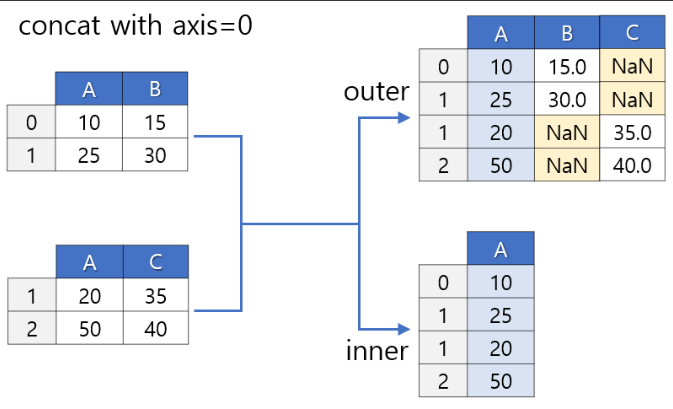

**1) 데이터 읽어오기**


**2) 데이터프레임 합치기**

- 이제 **concat()** 함수를 사용해 두 데이터프레임을 합쳐보자.
- 세로로 합치므로 **axis=0** 옵션을 지정하거나 생략한다.

- 세로로 합해지면 인덱스 값이 중복될 수 있으므로 인덱스를 초기화한다.
- 또는, `ignore_index = True`로 설정하면 인덱스가 새로 생성됨

**3) 참고: 인구 변화량 시각화**

- y축에 여러 값을 표시할 수 있다. 이때는 범례를 표시하는 것이 좋다.

## 7.2.데이터프레임 조인(Merge)

- **merge()** 함수를 사용 두 데이터프레임을 지정한 키 값을 기준으로 병합할 수 있다.


- 결합 방법에는 4가지가 있다.

![이미지](https://vitalflux.com/wp-content/uploads/2023/01/SQL-Joins-explained-using-Sets-640x451.png)

- `pd.merge(left, right, how='inner', on=None, left_on=None, right_on=None, sort=False)`
    - left : 병합할 첫 번째 데이터프레임
    - right : 병합할 두 번째 데이터프레임
    - how : 병합 방식 (inner, outer, left, right)
    - on : 공통된 열(column)을 기준으로 병합
    - left_on : 왼쪽 데이터프레임에서 사용할 키(key)
    - right_on : 오른쪽 데이터프레임에서 사용할 키(key)
    - sort : 병합된 결과를 기준 열을 기준으로 정렬할지 여부 (False가 기본)

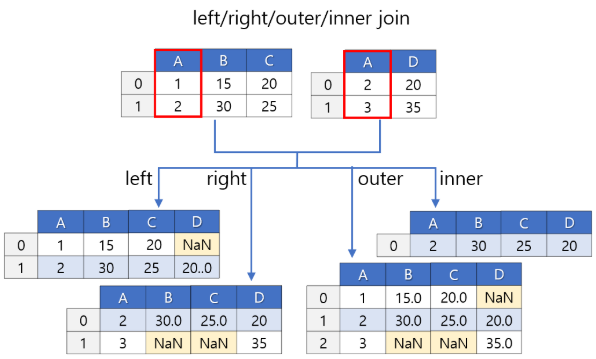

### 7.2.1.데이터 읽어오기

### 7.2.2.inner 조인

- 같은 이름의 열이 있으면 on 옵션을 지정하지 않아도 그 열을 기준으로 조인된다.
- 그래도 기준 열을 명시적으로 지정해 주기를 권고한다.
- how='inner' 옵션은 기본 옵션값이므로 생략할 수 있다.
- 공통된 값이 없으면 병합되지 않는다.

### 7.2.3.outer 조인

- how='outer' 옵션을 지정합니다.
- 일치하지 않는 부분은 `NaN`으로 채워진다.

### 7.2.4. 두 데이터의 기준 컬럼명이 다를 경우

## 7.3. Concat과 Merge의 차이점

| **기능**       | **`merge`**                | **`concat`**            |
|---------------|----------------------------|-------------------------|
| **결합 기준**  | 특정 키(`column`) 기준        | 축(`axis`) 기준         |
| **기준 열 필요** | 필요함                      | 필요 없음               |
| **유형**       | JOIN 방식 (`INNER`, `OUTER` 등) | 단순 연결 (위/아래/옆)    |
| **방향**       | 주로 **가로 (`axis=1`)**        | **행 (`axis=0`)**, **열 (`axis=1`)** |


